In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import time

print(f"PyTorch версия: {torch.__version__}")
print("Библиотеки успешно загружены!")

PyTorch версия: 2.11.0+cpu
Библиотеки успешно загружены!


In [19]:
# Константы
N_SAMPLES = 100000
N_PULSES = 500

print("Генерация параметров T1, T2, B0...")
# Генерируем случайные параметры в заданных диапазонах
T1 = np.random.uniform(100, 5000, N_SAMPLES)
T2 = np.random.uniform(20, 2000, N_SAMPLES)
B0 = np.random.uniform(-250, 250, N_SAMPLES)

# Списки констант для всех примеров
FA = np.sin(np.linspace(0, np.pi, N_PULSES)) * (60 * np.pi / 180) # Сила с которой бьем по вектору намагниченности
TR = np.random.uniform(10, 15, N_PULSES) #Пауза между ударами 

def run_bloch_simulation(T1, T2, B0, FA, TR, n_samples, n_pulses):
    print("Запуск симулятора Блоха (это займет несколько секунд)...")
    start_time = time.time()
    
    # Вектор намагниченности: M_x=0, M_y=0, M_z=1
    M = np.zeros((3, n_samples)) #Матрица 100000 векторов намагниченности по осям X Y Z
    M[2, :] = 1.0 #Все векторы изачально смотрят вверх (вдоль OZ)
    
    signals = np.zeros((n_samples, n_pulses), dtype=np.complex128) #Таблица для отпечатков сигналов
    
    for i in range(n_pulses):
        alpha = FA[i] #Текущий угол удара 
        tr = TR[i] # Текущее время паузы
        
        # 1. Удар импульсом (бьем по вектору волной). вычисляем координаты после поворота на угол в плоскости YZ
        M_new_y = M[1]*np.cos(alpha) + M[2]*np.sin(alpha)
        M_new_z = -M[1]*np.sin(alpha) + M[2]*np.cos(alpha)
        M[1] = M_new_y
        M[2] = M_new_z
        
        # 2. Снятие показаний(координата X становится реальной частью, а Y — мнимой)
        signals[:, i] = M[0] + 1j * M[1]
        
        # 3. Затухание (T2) и восстановление (T1)
        E1 = np.exp(-tr / T1)
        E2 = np.exp(-tr / T2)
        theta = 2 * np.pi * B0 * (tr / 1000.0) #Вращение вектора вокруг Z из за неидеальности магнитного поля(есть B0)

        #Обновление координат вектора
        M_xy = (M[0] + 1j * M[1]) * E2 * np.exp(-1j * theta) #комплексное число становится короче и поворачивается 
        M[0] = np.real(M_xy)
        M[1] = np.imag(M_xy)
        M[2] = M[2] * E1 + (1 - E1)
        
    print(f"Симуляция завершена за {time.time() - start_time:.2f} сек!")
    return signals

X_complex = run_bloch_simulation(T1, T2, B0, FA, TR, N_SAMPLES, N_PULSES)
print("Первые 10 отсчетов первого образца:")
print(X_complex[0, :10])

Генерация параметров T1, T2, B0...
Запуск симулятора Блоха (это займет несколько секунд)...
Симуляция завершена за 12.80 сек!
Первые 10 отсчетов первого образца:
[ 0.        +0.j          0.        +0.00659283j -0.00653793+0.01341442j
 -0.01188285+0.01094336j -0.01594049+0.02812344j -0.0256631 +0.01370634j
 -0.02791115+0.04697247j  0.0539434 +0.04142693j -0.06654677+0.04159348j
 -0.00970714+0.13631776j]


In [12]:
print("Начало препроцессинга данных...")

def add_complex_noise(signal, psnr=40):
    # Добавление гауссовского шума
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(psnr/10))
    noise_real = np.random.normal(0, np.sqrt(noise_power/2), signal.shape)
    noise_imag = np.random.normal(0, np.sqrt(noise_power/2), signal.shape)
    return signal + (noise_real + 1j * noise_imag)

# 1. Нормализация комплексных сигналов
norms = np.linalg.norm(X_complex, axis=1, keepdims=True)
X_normalized = X_complex / (norms + 1e-8)

# 2. Добавление шума
X_noisy = add_complex_noise(X_normalized, psnr=40)

# 3. Нормализация целевых переменных (T1, T2, B0)
scaler = MinMaxScaler()
Y = np.stack((T1, T2, B0), axis=1) 
Y_scaled = scaler.fit_transform(Y)

# Перевод в тензоры PyTorch
X_tensor = torch.tensor(X_noisy, dtype=torch.complex64)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32)

print("Данные успешно нормализованы и переведены в тензоры!")

Начало препроцессинга данных...
Данные успешно нормализованы и переведены в тензоры!


In [14]:
# Функция активации Complex Cardioid
class ComplexCardioid(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, z):
        # f(z) = 0.5 * (1 + cos(angle(z))) * z
        phase = torch.angle(z)
        multiplier = 0.5 * (1 + torch.cos(phase))
        return torch.complex(multiplier * z.real, multiplier * z.imag)

# Полносвязная комплекснозначная архитектура
class CVNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Входной слой -> Скрытый 1
        self.fc1 = nn.Linear(500, 512, dtype=torch.complex64)
        self.cardioid1 = ComplexCardioid()
        
        # Скрытый 1 -> Скрытый 2
        self.fc2 = nn.Linear(512, 256, dtype=torch.complex64)
        self.cardioid2 = ComplexCardioid()
        
        # Выходной слой (перевод в 3 вещественных числа)
        self.fc3 = nn.Linear(256, 3, dtype=torch.float32)

    def forward(self, x):
        x = self.fc1(x)
        x = self.cardioid1(x)
        
        x = self.fc2(x)
        x = self.cardioid2(x)
        
        # Переход от комплексных чисел к вещественным перед финальным слоем
        x = torch.abs(x) 
        
        x = self.fc3(x)
        return x

model = CVNN()
print("Архитектура сети:")
print(model)

Архитектура сети:
CVNN(
  (fc1): Linear(in_features=500, out_features=512, bias=True)
  (cardioid1): ComplexCardioid()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (cardioid2): ComplexCardioid()
  (fc3): Linear(in_features=256, out_features=3, bias=True)
)


In [ ]:
# Разбиваем данные: 80% обучение, 20% тест
dataset = TensorDataset(X_tensor, Y_tensor)#Склеиваем сигналы с параметрами тканей 
train_size = int(0.8 * N_SAMPLES)# Пропорция обучения
test_size = N_SAMPLES - train_size #Разделяем данные 

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Создаем DataLoader (батч = 256 для ускорения)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Примеров для обучения: {train_size}")
print(f"Примеров для тестирования: {test_size}")

Примеров для обучения: 80000
Примеров для тестирования: 20000


Запуск обучения нейросети...

Эпоха [1/15] | Ошибка (Loss): 0.021361
Эпоха [2/15] | Ошибка (Loss): 0.003450
Эпоха [3/15] | Ошибка (Loss): 0.002189
Эпоха [4/15] | Ошибка (Loss): 0.001730
Эпоха [5/15] | Ошибка (Loss): 0.001414
Эпоха [6/15] | Ошибка (Loss): 0.001208
Эпоха [7/15] | Ошибка (Loss): 0.001104
Эпоха [8/15] | Ошибка (Loss): 0.000981
Эпоха [9/15] | Ошибка (Loss): 0.000937
Эпоха [10/15] | Ошибка (Loss): 0.000908
Эпоха [11/15] | Ошибка (Loss): 0.000800
Эпоха [12/15] | Ошибка (Loss): 0.000802
Эпоха [13/15] | Ошибка (Loss): 0.000769
Эпоха [14/15] | Ошибка (Loss): 0.000760
Эпоха [15/15] | Ошибка (Loss): 0.000657

Обучение завершено!


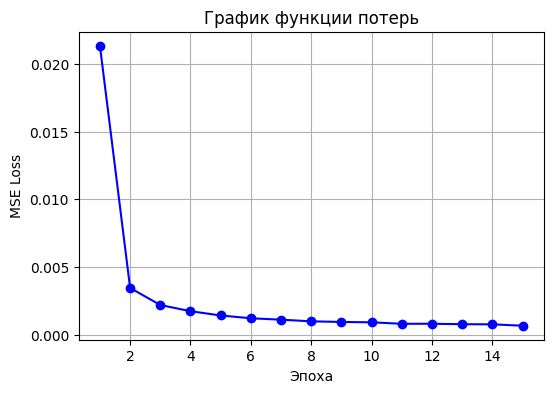

In [ ]:
criterion = nn.MSELoss() #Считаем ошибку
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#Учитель 
epochs = 15

print("Запуск обучения нейросети...\n")

train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad() #Перед тем как начать новый пример, мы стираем старые ошибки
        
        predictions = model(batch_X) #Сеть смотрит на 256 сигналов и пытается угадать их T1, T2, B_0
        loss = criterion(predictions, batch_Y) #Смотрим на ошибку сети 
        
        loss.backward()  #Исчисление Врингера
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Эпоха [{epoch+1}/{epochs}] | Ошибка (Loss): {avg_loss:.6f}")

print("\nОбучение завершено!")

# График падения ошибки
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_losses, marker='o', color='b')
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.grid()
plt.show()

Сбор предсказаний на тестовой выборке...


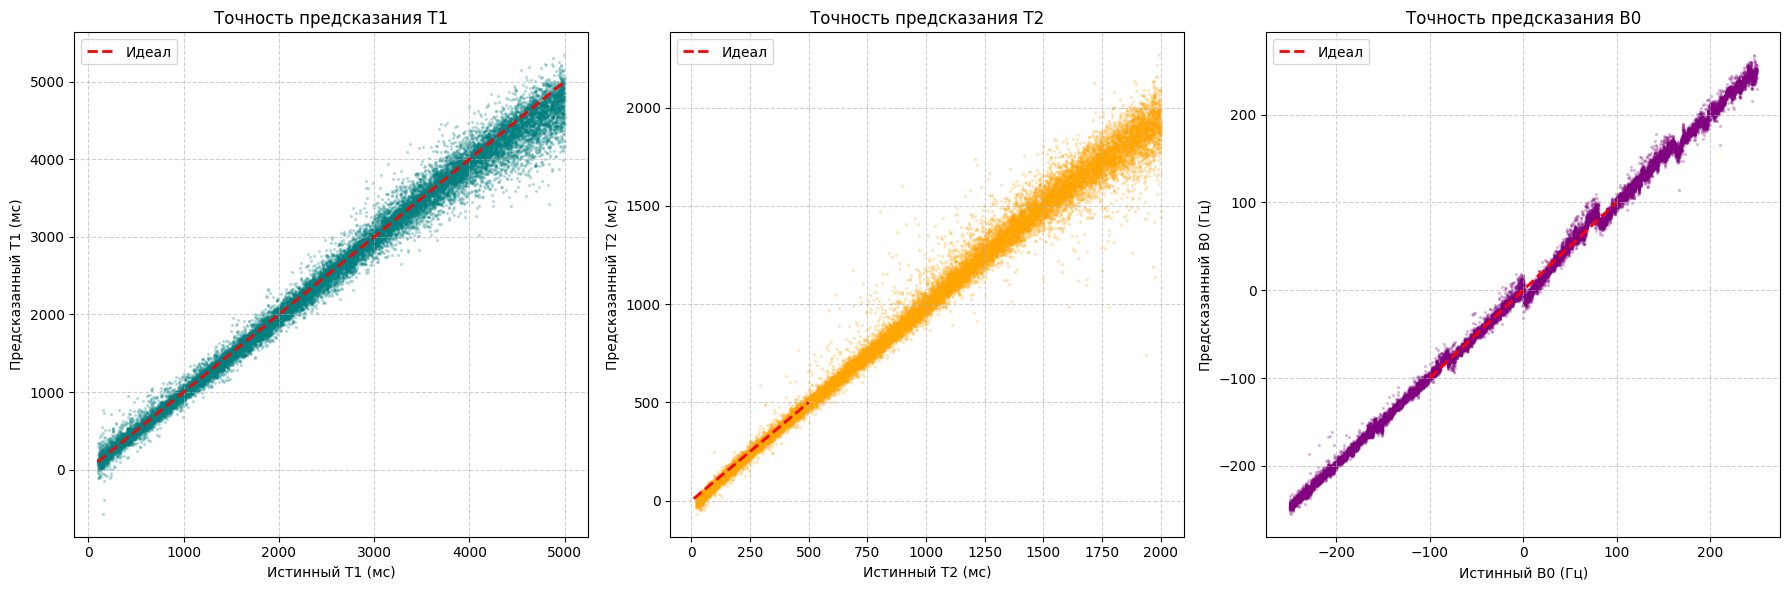

In [22]:
model.eval()
predictions_list = []
true_values_list = []

print("Сбор предсказаний на тестовой выборке...")
with torch.no_grad(): #Отключаем режим обучения 
    #Прогоняем тестовые данные
    for batch_X, batch_Y in test_loader:
        preds = model(batch_X)
        predictions_list.append(preds.numpy())
        true_values_list.append(batch_Y.numpy())

# Объединяем батчи
pred_Y_scaled = np.vstack(predictions_list)
true_Y_scaled = np.vstack(true_values_list)

# Возвращаем исходный масштаб значений (раснормализуем)
pred_Y = scaler.inverse_transform(pred_Y_scaled)
true_Y = scaler.inverse_transform(true_Y_scaled)

# Создаем "полотно" для 3 графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Список параметров и их индексов в массиве true_Y / pred_Y
params = [
    {"name": "T1", "unit": "мс", "index": 0, "color": "teal", "range": [100, 5000]},
    {"name": "T2", "unit": "мс", "index": 1, "color": "orange", "range": [10, 500]},
    {"name": "B0", "unit": "Гц", "index": 2, "color": "purple", "range": [-100, 100]}
]

for i, p in enumerate(params):
    ax = axes[i]
    idx = p["index"]
    
    # Рисуем точки (Реальность vs Предсказание)
    ax.scatter(true_Y[:, idx], pred_Y[:, idx], alpha=0.2, s=2, color=p["color"])
    
    # Рисуем идеальную диагональ
    limits = p["range"]
    ax.plot(limits, limits, 'r--', lw=2, label='Идеал')
    
    ax.set_title(f"Точность предсказания {p['name']}")
    ax.set_xlabel(f"Истинный {p['name']} ({p['unit']})")
    ax.set_ylabel(f"Предсказанный {p['name']} ({p['unit']})")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()



In [21]:
# Определяем рабочие диапазоны параметров (как в твоей симуляции)
ranges = {
    "T1": 5000 - 100,  # от 100 до 5000 мс
    "T2": 500 - 10,    # от 10 до 500 мс
    "B0": 200          # от -100 до 100 Гц (общий размах 200)
}

params_metadata = [
    {"name": "T1", "unit": "мс"},
    {"name": "T2", "unit": "мс"},
    {"name": "B0", "unit": "Гц"}
]

print("--- Итоговые результаты (Test Set) ---")

for i, p in enumerate(params_metadata):
    # 1. Считаем среднюю абсолютную ошибку (MAE)
    mae = np.mean(np.abs(true_Y[:, i] - pred_Y[:, i]))
    
    # 2. Считаем ошибку в процентах от диапазона
    param_range = list(ranges.values())[i]
    relative_error = (mae / param_range) * 100
    
    print(f"Параметр {p['name']}:")
    print(f"  - Ср. ошибка: {mae:.2f} {p['unit']}")
    print(f"  - В процентах: {relative_error:.2f}%")
    print("-" * 30)

--- Итоговые результаты (Test Set) ---
Параметр T1:
  - Ср. ошибка: 105.33 мс
  - В процентах: 2.15%
------------------------------
Параметр T2:
  - Ср. ошибка: 39.89 мс
  - В процентах: 8.14%
------------------------------
Параметр B0:
  - Ср. ошибка: 4.56 Гц
  - В процентах: 2.28%
------------------------------
